# 3. Post Processing PlatoSim light curves

This notebook is used to post-process the N-CAM light curves and merge them into a single final light curve per target source. 

In order to run this notebook, a PlatoSim installation is needed including the Python packages for the `platonium` toolkit. More information can be found on PlatoSim documentation.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
# Built-in
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import median_filter
from scipy.stats import binned_statistic
from pathlib import Path

# PlatoSim libraries
import platosim.slurm     as sm
import platosim.utilities as ut
from platosim.hpc          import HPC
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:70% !important; }</style>"))

In [80]:
# Global paths
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
idir = path / 'input'
odir = path / 'simulations/lcs'
vdir = odir / 'varsource'
sdir = odir / 'camera'
rdir = odir / 'mission'

## Generate HPC parameterisation file

In [600]:
# N = range(1,2)
# G = range(1,5)
# C = range(1,7)
# # Q = range(1,17)
# Q = range(9,25)
# filename = path / 'cluster_LOPN1.data'
# sm.getParamFile(N, G, C, Q, ofile=filename);

---
## Load data for notebook
---

In [4]:
# Directory to store and load simulations
filename = 'spikey_fiducial'
odir = sdir / filename

# Load variable source file and add flux column [ppt]
# varfile = vdir / 'varsource_spikey_fiducial.txt'
varfile = vdir / f'varsource_{filename}.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400
dv = dv.loc[::144]

In [5]:
# Load light curves
lcs = LightCurve(odir, mode="multi")
files = lcs.files(suffix='hdf5')
len(files)

384

In [7]:
# Save simulation table
dt = lcs.stat_sim_table(rdir / f'table_{filename}.ftr', clean=True, verbose=True)

[Warning]: Remove your "ofile" to use "clean" (if ".table" files still exists)


<IPython.core.display.Javascript object>


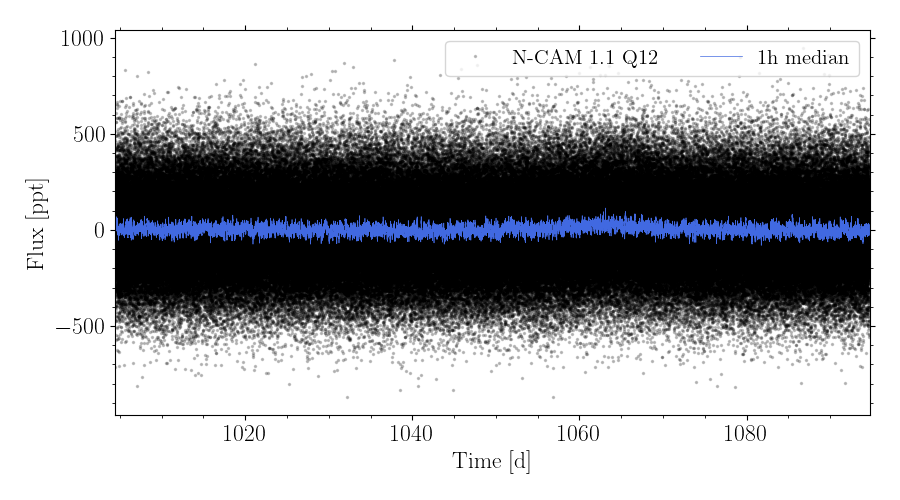

In [9]:
# Show a single light curve
lc = LightCurve(files[3], mode="single")
lc.plot(flux_unit='ppt', median_filter=1);

<IPython.core.display.Javascript object>


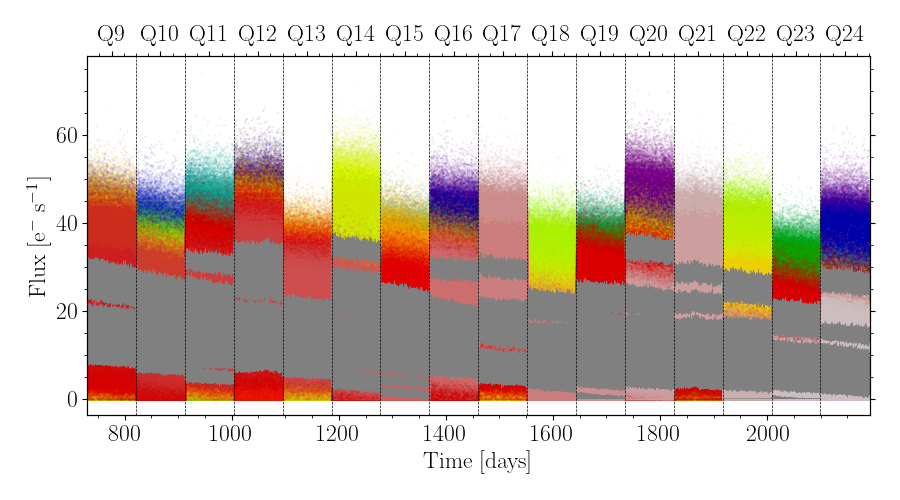

In [10]:
# Show all light curves from one group and quarter
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

---
## Data Reduction
---
Post-process all cameras across each quarter

In [11]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
binsize = 3600
# quarter0, quarter1 = 1, 16
quarter0, quarter1 = 9, 24 # [16, 24]

In [12]:
# Loop over each quarter, group, and camera
mask_updates = [0]
SPR = []
dq = pd.DataFrame()
for Q in tqdm(range(quarter0, quarter1+1), bar_format=ut.tqdmBar()):
    dg = pd.DataFrame()
    for G in range(1,5):
        dc = pd.DataFrame()
        for C in range(1,7):
            #---------------------
            # CAEMRA LIGHT CURVES:
            #---------------------
            f = lcs.files('hdf5', group=G, camera=C, quarter=Q)
            lc = LightCurve(f[0])
            dx = lc.data()   
            # Store data frames
            dc = pd.concat([dc, dx])
        #--------------------
        # GROUP LIGHT CURVES:
        #--------------------
        # Average data points of same timings
        dx = dc.groupby('time').mean().reset_index()
        dg = pd.concat([dg, dx])
    #---------------------
    # QUARTER LIGHT CURVE:
    #---------------------
    SPR.append(dt[dt.quarter == Q].SPR.mean())
    # Average data points of same timings
    dx = dg.groupby('time').mean().reset_index()
    # Bin data
    lc = LightCurve(dx, mode='multi')
    dx = lc.bin(binsize=binsize/3600, time_unit='h')
    dx.time *= 3600
    # Store group 
    dq = pd.concat([dq, dx])
    mask_updates.append(dq.shape[0])
# Deep copy
df = dq.copy()

100%|██████████████████████████████████████████████████| 16/16 [00:23<00:00,  1.


In [608]:
# Plot light curve in raw count [e-/s]
# lc = LightCurve(df, mode="multi")
# lc.plot(flux_unit='norm');

<IPython.core.display.Javascript object>


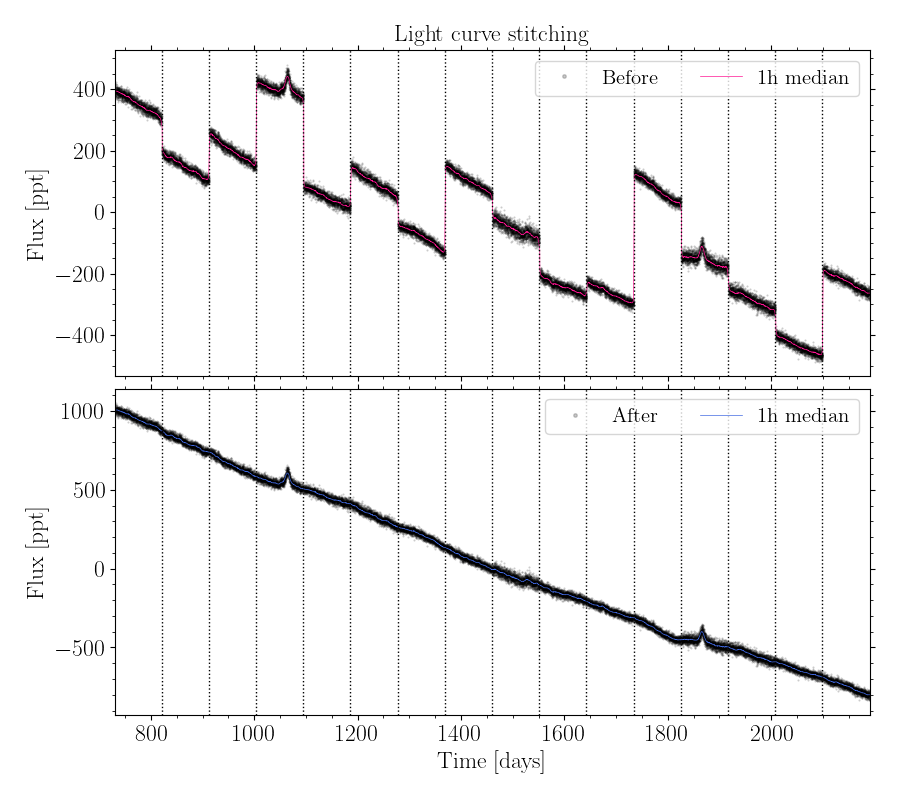

,time,flux,flux_stitch,flux0
0,6.311566e+07,18.182439,18.182439,18.182439
1,6.311926e+07,18.148705,18.148705,18.148705
2,6.312286e+07,18.406102,18.406102,18.406102
3,6.312646e+07,18.237159,18.237159,18.237159
4,6.313006e+07,17.902470,17.902470,17.902470


In [13]:
# Stitch the light curve
lc = LightCurve(df, mode="multi")
df0 = lc.stitch(method='lowess', segment=10, mask_updates=mask_updates, plot=True)
df0.head()

<IPython.core.display.Javascript object>


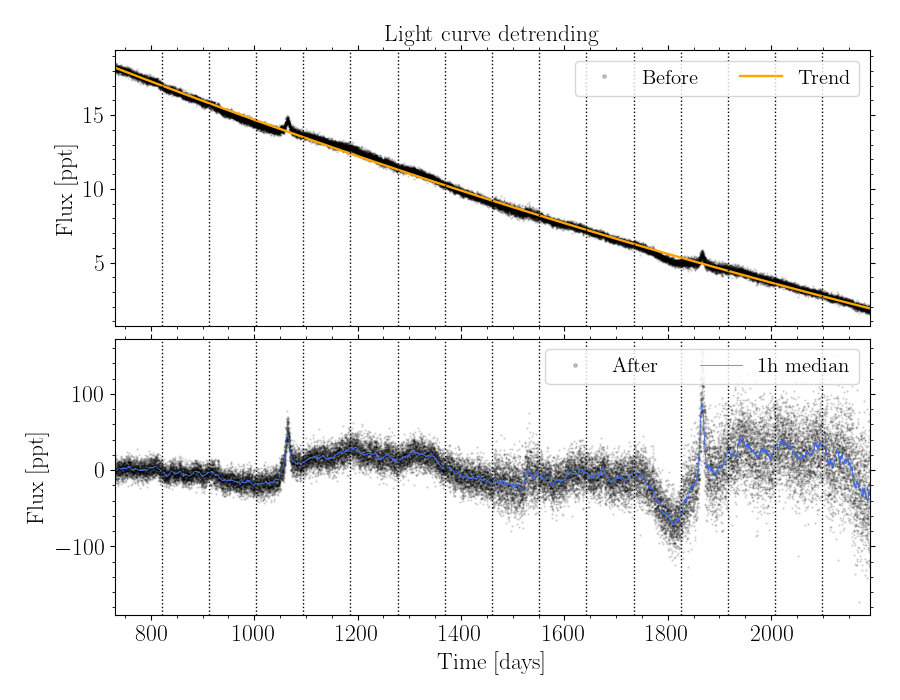

,time,flux,flux_stitch,flux0,flux_trend,flux_detrend
0,6.311566e+07,18.182439,18.182439,18.182439,18.217508,0.998175
1,6.311926e+07,18.148705,18.148705,18.148705,18.216944,0.996449
2,6.312286e+07,18.406102,18.406102,18.406102,18.216380,1.009873
3,6.312646e+07,18.237159,18.237159,18.237159,18.215817,1.001111
4,6.313006e+07,17.902470,17.902470,17.902470,18.215253,0.983722


In [14]:
# Perform detrending
df1 = lc.detrend(column='flux_stitch', model='poly', poly_degree=2, segments=False, plot=True)
df1.head()

<IPython.core.display.Javascript object>


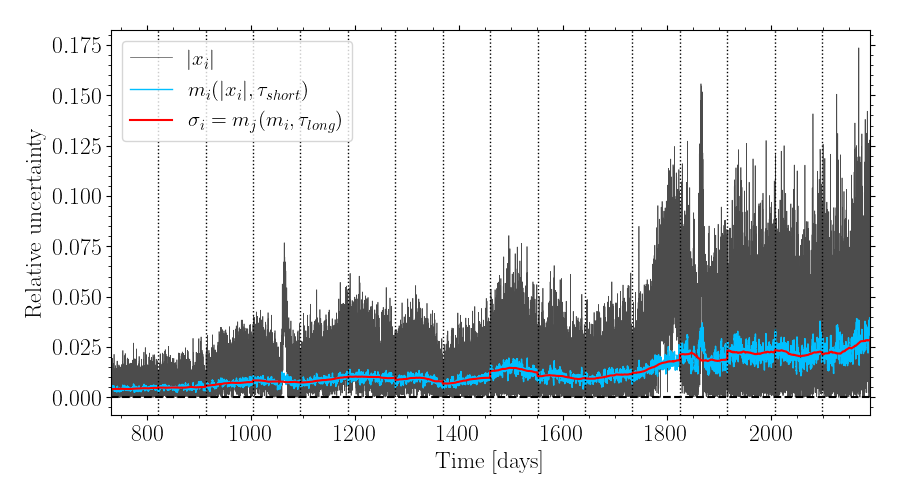

In [15]:
# Compute flux errors
df = lc.flux_error(column='flux_detrend', plot=True, short_filter=1, long_filter=50, type_filter=np.std)

In [68]:
# Correct for digitalization distortion
dx = df.copy()
corr = df.flux_trend / df.flux_trend.median()
dx.flux_detrend = (dx.flux_detrend - 1) * corr + 1
dx = dx.reset_index(drop=True)

<IPython.core.display.Javascript object>


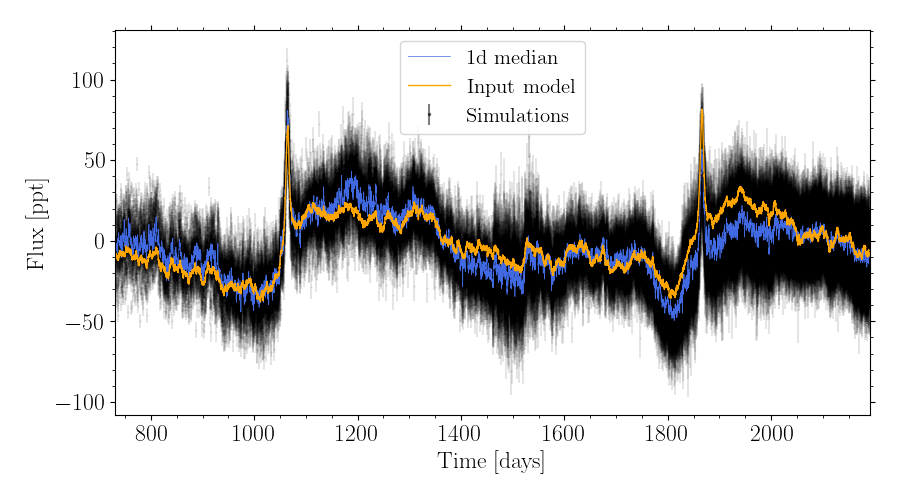

In [79]:
# Convert to days and ppt
time = dx.time / 86400
flux = (dx.flux_detrend - 1) * 1e3
ferr = dx.flux_err * 1e3
fmed = median_filter(flux, 24)

# Plot camera light curve with errors
fig1 = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', ms=1, alpha=0.1, zorder=1)
plt.errorbar(time[0], flux[0], yerr=ferr[0], fmt='.k', ms=3, alpha=0.5, zorder=1, label='Simulations')
plt.plot(time, fmed, '-', c='royalblue', lw=0.5, label='1d median')
plt.plot(dv.time, dv.flux, '-', c='orange', lw=1.0, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(time.min(), time.max())
plt.legend(loc='best')
plt.tight_layout();

### Bin data to 1-day cadence

In [72]:
# Light curve of 1-h cadence
dh = pd.DataFrame()
dh['time'] = dx.time / 86400
dh['flux'] = dx.flux_detrend
dh['flux_err'] = dx.flux_err
dh = dh.reset_index(drop=True)

In [73]:
# Bin light curve to 1-d cadence
dd = dh.copy()
dd.time *=86400
lc = LightCurve(dd, mode='multi')
dd = lc.bin(binsize=24)
dd.time /= 24
dd = dd.reset_index(drop=True)

<IPython.core.display.Javascript object>


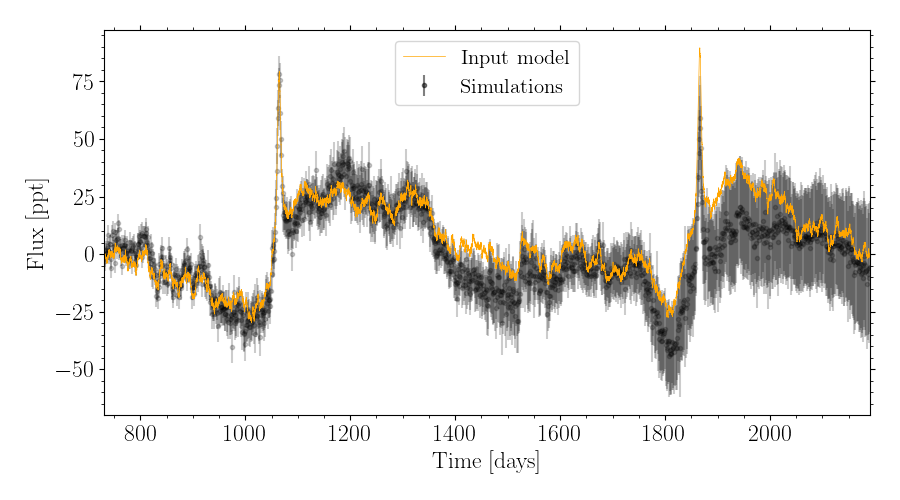

In [78]:
# Convert to days and ppt
time = dd.time
flux = (dd.flux - 1) *  1e3 
ferr = dd.flux_err * 1e3
fmed = median_filter(flux, 5)

# Plot light curve with 1-d cadence
fig2 = plt.figure(figsize=(9,5))
plt.errorbar(time, flux, yerr=ferr, fmt='.k', alpha=0.2, zorder=1)
plt.errorbar(time[0], flux[0], yerr=ferr[0], fmt='.k', alpha=0.5, zorder=1, label='Simulations')
plt.plot(dv.time, dv.flux+8, '-', c='orange', lw=0.5, label='Input model')
plt.xlabel('Time [days]')
plt.ylabel('Flux [ppt]')
plt.xlim(time.min(), time.max())
plt.legend(loc='upper center')
plt.tight_layout();

### Save light curves

In [617]:
# Save light curve of 1-h cadence
dh.to_feather(rdir / f'lc_{filename}_1h.ftr')
fig1.savefig(rdir / f'plot_{filename}_1h.png', bbox_inches='tight', dpi=200)

In [618]:
# Save light curve
dd.to_feather(rdir / f'lc_{filename}_1d.ftr')
fig2.savefig(rdir / f'plot_{filename}_1d.png', bbox_inches='tight', dpi=200)